# Pandas

## Importation des librairies

In [1]:
import numpy as np
import pandas as pd # openpyxl required to read Excel files
import matplotlib.pyplot as plt
import seaborn as sns

## Chargement des onglets du fichier Excel

In [2]:
excel_filename = "data/sanitoral.xlsx"

Plusieurs points de vigilance

- Le nombre de lignes avant les entêtes (headers) varie d'un onglet à l'autre.
- Les colonnes avec les identifiants des projets portent des noms différents (toutes renommées `Project ID`).

In [3]:
df_country_profile = pd.read_excel(excel_filename, sheet_name="Country_Profiles", header=1)
df_country_profile.head()

,Country,Region,Type
0,France,Western Europe,Affiliate
1,Belgique,Western Europe,Affiliate
2,Hollande,Western Europe,Affiliate
3,Luxembourg,Western Europe,Affiliate
4,Italie,Western Europe,Affiliate


In [4]:
df_project_location = pd.read_excel(excel_filename, sheet_name="Projects_Locations", header=1)
df_project_location.head()

,Project ID,Country
0,1,Equateur
1,2,France
2,3,Liban
3,4,Egypte
4,5,Afrique du Sud


In [5]:
df_project_type = pd.read_excel(excel_filename, sheet_name="Project type", header=3)
df_project_type.head()

,Project ID,Project Type
0,1,Marketing - Launch of new product
1,2,Marketing - Launch of new product
2,3,Marketing - Launch of new product
3,4,Marketing - Launch of new product
4,5,Marketing - Launch of new product


In [6]:
df_planned = pd.read_excel(excel_filename, sheet_name="Projects_plans", header=2)
df_planned.rename(columns={"Planned_Delivrable":"Planned_Deliverables"}, inplace=True)
df_planned.head()

,Project ID,Phase,Start Date,Planned_Duration,Planned_Cost,Planned_Deliverables
0,1,Phase 1 - Planning,2018-01-16,196,50000,10
1,1,Phase 2 - Initiation,2018-01-31,15,100000,17
2,1,Phase 3 - Implementation,2018-04-17,197,150000,26
3,1,Phase 4 - Manufacturing,2018-10-10,61,450000,23
4,2,Phase 1 - Planning,2018-01-30,16,100000,6


In [7]:
df_actual_cost = pd.read_excel(excel_filename, sheet_name="Actual_Costs", header=3)
df_actual_cost.rename(columns={"Proj_ID":"Project ID"}, inplace=True)
df_actual_cost.head()

,Project ID,Phase,Actual_Cost
0,1,Phase 1 - Planning,59600
1,2,Phase 1 - Planning,86700
2,3,Phase 1 - Planning,65800
3,4,Phase 1 - Planning,65100
4,5,Phase 1 - Planning,52600


In [8]:
df_actual_duration = pd.read_excel(excel_filename, sheet_name="Actual_Duration", header=5)
df_actual_duration.rename(columns={"Project":"Project ID"}, inplace=True)
df_actual_duration.head()

,Project ID,Phase,Actual_Duration
0,1,Phase 1 - Planning,196
1,1,Phase 2 - Initiation,7
2,1,Phase 3 - Implementation,176
3,1,Phase 4 - Manufacturing,64
4,2,Phase 1 - Planning,16


In [9]:
df_actual_deliverable = pd.read_excel(excel_filename, sheet_name="Actual_Delivrable", header=3)
df_actual_deliverable.rename(columns={"ID":"Project ID"}, inplace=True)
df_actual_deliverable.head()

,Project ID,Phase,Actual_Deliverables
0,1,Phase 1 - Planning,10
1,1,Phase 2 - Initiation,16
2,1,Phase 3 - Implementation,25
3,1,Phase 4 - Manufacturing,23
4,2,Phase 1 - Planning,6


## Analyse exploratoire

In [10]:
df_country_profile.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Country  52 non-null     str  
 1   Region   52 non-null     str  
 2   Type     52 non-null     str  
dtypes: str(3)
memory usage: 1.3 KB


In [11]:
df_project_location.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Project ID  104 non-null    int64
 1   Country     104 non-null    str  
dtypes: int64(1), str(1)
memory usage: 1.8 KB


In [12]:
df_project_type.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Project ID    104 non-null    int64
 1   Project Type  104 non-null    str  
dtypes: int64(1), str(1)
memory usage: 1.8 KB


In [13]:
df_planned.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Project ID            520 non-null    int64         
 1   Phase                 520 non-null    str           
 2   Start Date            520 non-null    datetime64[us]
 3   Planned_Duration      520 non-null    int64         
 4   Planned_Cost          520 non-null    int64         
 5   Planned_Deliverables  520 non-null    int64         
dtypes: datetime64[us](1), int64(4), str(1)
memory usage: 24.5 KB


In [14]:
df_actual_duration.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Project ID       520 non-null    int64
 1   Phase            520 non-null    str  
 2   Actual_Duration  520 non-null    int64
dtypes: int64(2), str(1)
memory usage: 12.3 KB


In [15]:
df_actual_cost.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Project ID   520 non-null    int64
 1   Phase        520 non-null    str  
 2   Actual_Cost  520 non-null    int64
dtypes: int64(2), str(1)
memory usage: 12.3 KB


In [16]:
df_actual_deliverable.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Project ID           520 non-null    int64
 1   Phase                520 non-null    str  
 2   Actual_Deliverables  520 non-null    int64
dtypes: int64(2), str(1)
memory usage: 12.3 KB


## Jointure

In [17]:
df_merge = pd.merge(df_country_profile, df_project_location)
df_merge.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Country     104 non-null    str  
 1   Region      104 non-null    str  
 2   Type        104 non-null    str  
 3   Project ID  104 non-null    int64
dtypes: int64(1), str(3)
memory usage: 3.4 KB


In [18]:
df_merge = pd.merge(df_merge, df_project_type)
df_merge.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Country       104 non-null    str  
 1   Region        104 non-null    str  
 2   Type          104 non-null    str  
 3   Project ID    104 non-null    int64
 4   Project Type  104 non-null    str  
dtypes: int64(1), str(4)
memory usage: 4.2 KB


In [19]:
df_merge = pd.merge(df_merge, df_planned)
df_merge.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Country               520 non-null    str           
 1   Region                520 non-null    str           
 2   Type                  520 non-null    str           
 3   Project ID            520 non-null    int64         
 4   Project Type          520 non-null    str           
 5   Phase                 520 non-null    str           
 6   Start Date            520 non-null    datetime64[us]
 7   Planned_Duration      520 non-null    int64         
 8   Planned_Cost          520 non-null    int64         
 9   Planned_Deliverables  520 non-null    int64         
dtypes: datetime64[us](1), int64(4), str(5)
memory usage: 40.8 KB


In [20]:
df_merge = pd.merge(df_merge, df_actual_duration)
df_merge.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Country               520 non-null    str           
 1   Region                520 non-null    str           
 2   Type                  520 non-null    str           
 3   Project ID            520 non-null    int64         
 4   Project Type          520 non-null    str           
 5   Phase                 520 non-null    str           
 6   Start Date            520 non-null    datetime64[us]
 7   Planned_Duration      520 non-null    int64         
 8   Planned_Cost          520 non-null    int64         
 9   Planned_Deliverables  520 non-null    int64         
 10  Actual_Duration       520 non-null    int64         
dtypes: datetime64[us](1), int64(5), str(5)
memory usage: 44.8 KB


In [21]:
df_merge = pd.merge(df_merge, df_actual_cost)
df_merge.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Country               520 non-null    str           
 1   Region                520 non-null    str           
 2   Type                  520 non-null    str           
 3   Project ID            520 non-null    int64         
 4   Project Type          520 non-null    str           
 5   Phase                 520 non-null    str           
 6   Start Date            520 non-null    datetime64[us]
 7   Planned_Duration      520 non-null    int64         
 8   Planned_Cost          520 non-null    int64         
 9   Planned_Deliverables  520 non-null    int64         
 10  Actual_Duration       520 non-null    int64         
 11  Actual_Cost           520 non-null    int64         
dtypes: datetime64[us](1), int64(6), str(5)
memory usage: 48.9 KB


In [22]:
df_merge = pd.merge(df_merge, df_actual_deliverable)
df_merge.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Country               520 non-null    str           
 1   Region                520 non-null    str           
 2   Type                  520 non-null    str           
 3   Project ID            520 non-null    int64         
 4   Project Type          520 non-null    str           
 5   Phase                 520 non-null    str           
 6   Start Date            520 non-null    datetime64[us]
 7   Planned_Duration      520 non-null    int64         
 8   Planned_Cost          520 non-null    int64         
 9   Planned_Deliverables  520 non-null    int64         
 10  Actual_Duration       520 non-null    int64         
 11  Actual_Cost           520 non-null    int64         
 12  Actual_Deliverables   520 non-null    int64         
dtypes: datetime64[us](1), int64(7),

In [23]:
for project_type in sorted(pd.unique(df_merge["Project Type"])):
    df_tmp = df_merge[ (df_merge["Project Type"] == project_type) ]
    n = df_tmp.shape[0]
    print(*sorted(pd.unique(df_tmp["Phase"])), sep="\n")
    df_tmp = df_tmp[["Project ID","Phase"]].groupby("Project ID").agg({ "Phase": [ "count", "nunique" ] })
    # reshape() : 1 seul argument pour passer d'une matrice (2D) à un vecteur (1D)
    # -1 signifie "calcul automatique de la taille du vecteur" (nb lignes × nb colonnes)
    a = pd.unique(df_tmp.to_numpy().reshape(-1))
    assert len(a) == 1
    m = a[0]
    print(f"Les {n // m} projets de type ({project_type}) ont tous {m} phases.")

Phase A - Initiation
Phase B - Preparation
Phase C - Development
Phase D - Testing
Phase E - Deployment
Phase F - Post-deployment
Les 52 projets de type (IT -  CRM Implementation) ont tous 6 phases.
Phase 1 - Planning
Phase 2 - Initiation
Phase 3 - Implementation
Phase 4 - Manufacturing
Les 52 projets de type (Marketing - Launch of new product) ont tous 4 phases.


## Calculs

In [24]:
df_merge["Delay"]         = (df_merge["Actual_Duration"] - df_merge["Planned_Duration"]).clip(lower=0) # max(0, actual - planned)
df_merge["Is_Late"]       = (df_merge["Delay"] > 0)
df_merge["Start_Month"]   = df_merge["Start Date"].dt.month
df_merge["Start_Quarter"] = df_merge["Start Date"].dt.quarter
df_merge["Start_Year"]    = df_merge["Start Date"].dt.year
df_merge.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Country               520 non-null    str           
 1   Region                520 non-null    str           
 2   Type                  520 non-null    str           
 3   Project ID            520 non-null    int64         
 4   Project Type          520 non-null    str           
 5   Phase                 520 non-null    str           
 6   Start Date            520 non-null    datetime64[us]
 7   Planned_Duration      520 non-null    int64         
 8   Planned_Cost          520 non-null    int64         
 9   Planned_Deliverables  520 non-null    int64         
 10  Actual_Duration       520 non-null    int64         
 11  Actual_Cost           520 non-null    int64         
 12  Actual_Deliverables   520 non-null    int64         
 13  Delay                 520 non-n

## Agrégation

In [25]:
df_project = df_merge.groupby("Project ID").agg({
    "Planned_Duration": "sum",
    "Planned_Cost": "sum",
    "Planned_Deliverables": "sum",
    "Phase": "count",
    "Delay": "sum",
    "Is_Late": "any",
    "Start Date": "min",
}).reset_index()
df_project.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Project ID            104 non-null    int64         
 1   Planned_Duration      104 non-null    int64         
 2   Planned_Cost          104 non-null    int64         
 3   Planned_Deliverables  104 non-null    int64         
 4   Phase                 104 non-null    int64         
 5   Delay                 104 non-null    int64         
 6   Is_Late               104 non-null    bool          
 7   Start Date            104 non-null    datetime64[us]
dtypes: bool(1), datetime64[us](1), int64(6)
memory usage: 5.9 KB


## Visualisation

In [26]:
df_tmp = df_project[["Project ID","Delay"]].groupby("Delay").count().reset_index()
df_tmp.rename(columns={"Project ID":"Project Count"}, inplace=True)
delay_min = df_tmp["Delay"].min()
delay_max = df_tmp["Delay"].max()
count_max = df_tmp["Project Count"].max()
print(f"Le retard cumulé par projet varie entre {delay_min} et {delay_max}.")
print(f"Il y a au plus {count_max} projet(s) par valeur de retard cumulé.")

Le retard cumulé par projet varie entre 0 et 163.
Il y a au plus 9 projet(s) par valeur de retard cumulé.


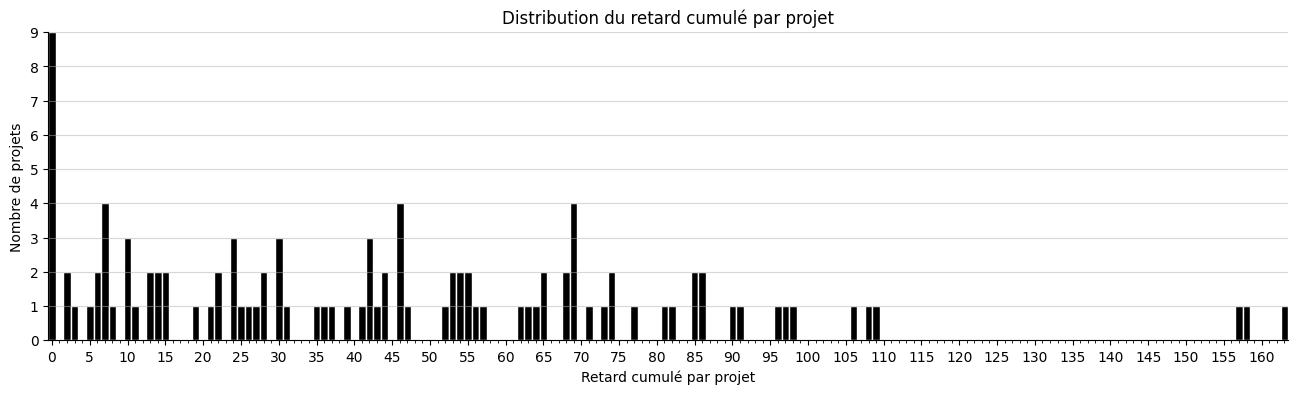

In [27]:
bins = np.arange(delay_min, delay_max + 2) - 0.5 # 1 bin = 1 value
ax = df_project["Delay"].plot.hist(bins=bins, color="black", edgecolor="white", figsize=(16,4))
plt.title("Distribution du retard cumulé par projet")
plt.ylabel("Nombre de projets")
plt.xlabel("Retard cumulé par projet")
plt.xlim(delay_min - 0.5, delay_max + 0.5)
plt.xticks(range(0,delay_max+1,5))
plt.xticks(range(0,delay_max+1), minor=True)
plt.ylim(0, 9)
plt.yticks(range(0,count_max+1))
plt.grid(axis="y", alpha=.5)
ax.spines["top"   ].set_visible(False)
ax.spines["right" ].set_visible(False)
plt.show()

# SciKit Learn

## Préparation des données

In [28]:
# Sélection des variables quantitatives
df_data = df_merge[["Planned_Duration","Planned_Cost","Planned_Deliverables","Actual_Duration","Actual_Cost","Actual_Deliverables"]]
df_data.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Planned_Duration      520 non-null    int64
 1   Planned_Cost          520 non-null    int64
 2   Planned_Deliverables  520 non-null    int64
 3   Actual_Duration       520 non-null    int64
 4   Actual_Cost           520 non-null    int64
 5   Actual_Deliverables   520 non-null    int64
dtypes: int64(6)
memory usage: 24.5 KB


In [29]:
# Transformation de Project Type en matrice binaire
for project_type in sorted(pd.unique(df_merge["Project Type"])):
    column = f"Projet {project_type.split()[0]}"
    df_data[column] = (df_merge["Project Type"] == project_type).astype(int)
df_data.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Planned_Duration      520 non-null    int64
 1   Planned_Cost          520 non-null    int64
 2   Planned_Deliverables  520 non-null    int64
 3   Actual_Duration       520 non-null    int64
 4   Actual_Cost           520 non-null    int64
 5   Actual_Deliverables   520 non-null    int64
 6   Projet IT             520 non-null    int64
 7   Projet Marketing      520 non-null    int64
dtypes: int64(8)
memory usage: 32.6 KB


In [30]:
# Transformation de Phase en matrice binaire (autre méthode adaptée lorsqu'il y a beaucoup de 0)
columns = np.sort(pd.unique(df_merge["Phase"]).map(lambda phase: phase[:7]))
df_data[columns] = 0
for index in df_data.index:
    column = df_merge.loc[index,"Phase"][:7]
    df_data.loc[index,column] = 1
df_data.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Planned_Duration      520 non-null    int64
 1   Planned_Cost          520 non-null    int64
 2   Planned_Deliverables  520 non-null    int64
 3   Actual_Duration       520 non-null    int64
 4   Actual_Cost           520 non-null    int64
 5   Actual_Deliverables   520 non-null    int64
 6   Projet IT             520 non-null    int64
 7   Projet Marketing      520 non-null    int64
 8   Phase 1               520 non-null    int64
 9   Phase 2               520 non-null    int64
 10  Phase 3               520 non-null    int64
 11  Phase 4               520 non-null    int64
 12  Phase A               520 non-null    int64
 13  Phase B               520 non-null    int64
 14  Phase C               520 non-null    int64
 15  Phase D               520 non-null    int64
 16  Phase E            

In [31]:
# Start_Date est une variable temporelle : transformation en cycle de mois
df_data[f"Start_Month_cos"] = df_merge["Start_Month"].map(lambda month:np.cos(2*np.pi*(month-1)/12))
df_data[f"Start_Month_sin"] = df_merge["Start_Month"].map(lambda month:np.sin(2*np.pi*(month-1)/12))
df_data.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Planned_Duration      520 non-null    int64  
 1   Planned_Cost          520 non-null    int64  
 2   Planned_Deliverables  520 non-null    int64  
 3   Actual_Duration       520 non-null    int64  
 4   Actual_Cost           520 non-null    int64  
 5   Actual_Deliverables   520 non-null    int64  
 6   Projet IT             520 non-null    int64  
 7   Projet Marketing      520 non-null    int64  
 8   Phase 1               520 non-null    int64  
 9   Phase 2               520 non-null    int64  
 10  Phase 3               520 non-null    int64  
 11  Phase 4               520 non-null    int64  
 12  Phase A               520 non-null    int64  
 13  Phase B               520 non-null    int64  
 14  Phase C               520 non-null    int64  
 15  Phase D               520 non-null

In [32]:
df_month_cycle = pd.concat([ df_merge[["Start_Month"]], df_data[["Start_Month_cos","Start_Month_sin"]] ], axis=1)
df_month_cycle = df_month_cycle.drop_duplicates().sort_values("Start_Month").reset_index(drop=True)
df_month_cycle["Start_Month_text"] = "JAN FEB MAR APR MAY JUN JUL AUG SEP OCT NOV DEC".split()
df_month_cycle

,Start_Month,Start_Month_cos,Start_Month_sin,Start_Month_text
0,1,1.000000e+00,0.000000e+00,JAN
1,2,8.660254e-01,5.000000e-01,FEB
2,3,5.000000e-01,8.660254e-01,MAR
3,4,6.123234e-17,1.000000e+00,APR
4,5,-5.000000e-01,8.660254e-01,MAY
5,6,-8.660254e-01,5.000000e-01,JUN
6,7,-1.000000e+00,1.224647e-16,JUL
7,8,-8.660254e-01,-5.000000e-01,AUG
8,9,-5.000000e-01,-8.660254e-01,SEP
9,10,-1.836970e-16,-1.000000e+00,OCT


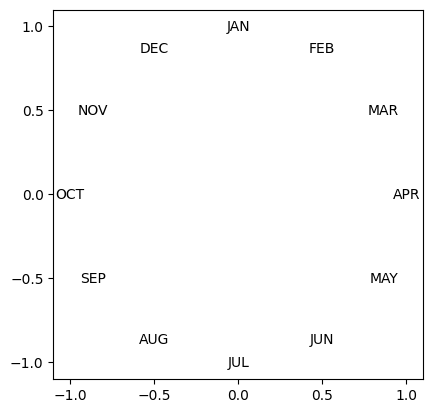

In [33]:
fig, ax = plt.subplots()
ax.set_aspect("equal", adjustable="box")
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xticks(np.linspace(-1,1,5))
plt.yticks(np.linspace(-1,1,5))
for ind, row in df_month_cycle.iterrows():
    plt.text(
        x=row["Start_Month_sin"], y=row["Start_Month_cos"],
        s=row["Start_Month_text"], ha="center", va="center",
    )
plt.show()

In [34]:
df_data.to_csv("data/sklearn_ready.csv")

In [35]:
df_results = pd.DataFrame(columns=[
    "R² score (train)", "R² score (test)",
    "MSE (train)", "MSE (test)",
    "MAE (train)", "MAE (test)",
])
df_results.index.name = "Model"
df_results

,R² score (train),R² score (test),MSE (train),MSE (test),MAE (train),MAE (test)
Model,,,,,,


## Création des jeux d'entraînement/test

In [36]:
df_X = df_data[[
    "Planned_Duration", "Planned_Cost", "Planned_Deliverables",
    "Projet IT", "Projet Marketing",
    "Phase 1", "Phase 2", "Phase 3", "Phase 4",
    "Phase A", "Phase B", "Phase C", "Phase D", "Phase E", "Phase F",
    "Start_Month_cos", "Start_Month_sin",
]]
df_X.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Planned_Duration      520 non-null    int64  
 1   Planned_Cost          520 non-null    int64  
 2   Planned_Deliverables  520 non-null    int64  
 3   Projet IT             520 non-null    int64  
 4   Projet Marketing      520 non-null    int64  
 5   Phase 1               520 non-null    int64  
 6   Phase 2               520 non-null    int64  
 7   Phase 3               520 non-null    int64  
 8   Phase 4               520 non-null    int64  
 9   Phase A               520 non-null    int64  
 10  Phase B               520 non-null    int64  
 11  Phase C               520 non-null    int64  
 12  Phase D               520 non-null    int64  
 13  Phase E               520 non-null    int64  
 14  Phase F               520 non-null    int64  
 15  Start_Month_cos       520 non-null

In [37]:
df_y = df_data[[ "Actual_Duration", "Actual_Cost", "Actual_Deliverables" ]]
df_y.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Actual_Duration      520 non-null    int64
 1   Actual_Cost          520 non-null    int64
 2   Actual_Deliverables  520 non-null    int64
dtypes: int64(3)
memory usage: 12.3 KB


In [38]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_X, df_y, test_size=0.20, random_state=42)
print(f"Train: {len(X_train)} lines")
print(f"Test: {len(X_test)} lines")

Train: 416 lines
Test: 104 lines


## DummyRegressor (mean)

In [39]:
from sklearn.dummy import DummyRegressor
model = DummyRegressor(strategy="mean")
model

,"strategy strategy: {""mean"", ""median"", ""quantile"", ""constant""}, default=""mean""Strategy to use to generate predictions.* ""mean"": always predicts the mean of the training set* ""median"": always predicts the median of the training set* ""quantile"": always predicts a specified quantile of the training set, provided with the quantile parameter.* ""constant"": always predicts a constant value that is provided by the user.",'mean'
,"constant constant: int or float or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
,"quantile quantile: float in [0.0, 1.0], default=NoneThe quantile to predict using the ""quantile"" strategy. A quantile of0.5 corresponds to the median, while 0.0 to the minimum and 1.0 to themaximum.",None


In [40]:
model.fit(X_train, y_train)

,"strategy strategy: {""mean"", ""median"", ""quantile"", ""constant""}, default=""mean""Strategy to use to generate predictions.* ""mean"": always predicts the mean of the training set* ""median"": always predicts the median of the training set* ""quantile"": always predicts a specified quantile of the training set, provided with the quantile parameter.* ""constant"": always predicts a constant value that is provided by the user.",'mean'
,"constant constant: int or float or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
,"quantile quantile: float in [0.0, 1.0], default=NoneThe quantile to predict using the ""quantile"" strategy. A quantile of0.5 corresponds to the median, while 0.0 to the minimum and 1.0 to themaximum.",None


In [41]:
y_predict_train = model.predict(X_train)
y_predict_test  = model.predict(X_test )
from sklearn.metrics import r2_score, mean_squared_error as mse, mean_absolute_error as mae
df_results.loc["DummyRegressor (mean)"] = [
    r2_score(y_train, y_predict_train), r2_score(y_test, y_predict_test),
    mse(y_train, y_predict_train), mse(y_test, y_predict_test),
    mae(y_train, y_predict_train), mae(y_test, y_predict_test),
]
df_results.loc["DummyRegressor (mean)"]

R² score (train)    0.000000e+00
R² score (test)    -1.140513e-02
MSE (train)         1.506286e+10
MSE (test)          1.118783e+10
MAE (train)         4.503380e+04
MAE (test)          4.465488e+04
Name: DummyRegressor (mean), dtype: float64

## LinearRegression

In [42]:
from sklearn.linear_model import LinearRegression
model = LinearRegression() # positive=False : Ordinary Least Squares
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [43]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [44]:
y_predict_train = model.predict(X_train)
y_predict_test  = model.predict(X_test )
df_results.loc["LinearRegression"] = [
    r2_score(y_train, y_predict_train), r2_score(y_test, y_predict_test),
    mse(y_train, y_predict_train), mse(y_test, y_predict_test),
    mae(y_train, y_predict_train), mae(y_test, y_predict_test),
]
df_results.loc["LinearRegression"]

R² score (train)    8.227841e-01
R² score (test)     8.218847e-01
MSE (train)         2.384902e+08
MSE (test)          2.698647e+08
MAE (train)         4.573859e+03
MAE (test)          5.125361e+03
Name: LinearRegression, dtype: float64

In [45]:
df_coef = pd.DataFrame(model.coef_, index=df_y.columns, columns=df_X.columns)
df_coef

,Planned_Duration,Planned_Cost,Planned_Deliverables,Projet IT,Projet Marketing,Phase 1,Phase 2,Phase 3,Phase 4,Phase A,Phase B,Phase C,Phase D,Phase E,Phase F,Start_Month_cos,Start_Month_sin
Actual_Duration,0.630175,3.259895e-05,0.226593,4.111210,-4.111210,3.723562,-3.168301,5.342678,-10.009149,-0.015645,-6.584308,2.857467,6.336350,1.244904,0.272441,-3.534266,-1.034594
Actual_Cost,-41.623975,1.007345e+00,-185.876267,-9535.649580,9535.649580,-13918.138479,-7823.180535,-1710.671533,32987.640126,-1007.649336,1554.710227,1884.451116,14454.824646,-26705.126485,283.140252,-174.922414,1003.003402
Actual_Deliverables,-0.001332,-3.473328e-07,0.890363,-0.482252,0.482252,0.057231,-0.206198,0.307438,0.323781,-0.046603,0.398642,-0.608615,-0.330087,-0.072475,0.176886,0.152785,0.109907


In [46]:
df_intercept = pd.DataFrame(model.intercept_, index=df_y.columns, columns=["intercept"])
df_intercept

,intercept
Actual_Duration,16.228513
Actual_Cost,16911.443746
Actual_Deliverables,0.330274


In [47]:
for y in df_y.columns:
    print(df_intercept.loc[y])
    print()
    print(df_coef.loc[y].T.sort_values(ascending=False))
    print()

intercept    16.228513
Name: Actual_Duration, dtype: float64

Phase D                  6.336350
Phase 3                  5.342678
Projet IT                4.111210
Phase 1                  3.723562
Phase C                  2.857467
Phase E                  1.244904
Planned_Duration         0.630175
Phase F                  0.272441
Planned_Deliverables     0.226593
Planned_Cost             0.000033
Phase A                 -0.015645
Start_Month_sin         -1.034594
Phase 2                 -3.168301
Start_Month_cos         -3.534266
Projet Marketing        -4.111210
Phase B                 -6.584308
Phase 4                -10.009149
Name: Actual_Duration, dtype: float64

intercept    16911.443746
Name: Actual_Cost, dtype: float64

Phase 4                 32987.640126
Phase D                 14454.824646
Projet Marketing         9535.649580
Phase C                  1884.451116
Phase B                  1554.710227
Start_Month_sin          1003.003402
Phase F                   283.140252
P

## RandomForestRegressor

In [48]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(random_state=42)
model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [49]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [50]:
y_predict_train = model.predict(X_train)
y_predict_test  = model.predict(X_test )
df_results.loc["RandomForestRegressor"] = [
    r2_score(y_train, y_predict_train), r2_score(y_test, y_predict_test),
    mse(y_train, y_predict_train), mse(y_test, y_predict_test),
    mae(y_train, y_predict_train), mae(y_test, y_predict_test),
]
df_results.loc["RandomForestRegressor"]

R² score (train)    9.476432e-01
R² score (test)     6.620786e-01
MSE (train)         3.711360e+07
MSE (test)          3.447485e+08
MAE (train)         1.587857e+03
MAE (test)          4.808756e+03
Name: RandomForestRegressor, dtype: float64

## GridSearchCV (supervision) + joblib (sauvegarde de modèle)

In [51]:
from sklearn.model_selection import GridSearchCV
import joblib
import os

force_compute = False
filename = "data/grid_search_cv__random_forest_regressor.pkl"

if force_compute or not os.path.exists(filename):
    print("Computing model")
    estimator = RandomForestRegressor(random_state=42)
    param_grid = {
        "n_estimators": [50, 100, 200],
        "max_depth": [5, 10, 15, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ['sqrt', 'log2'],
    }
    grid_search = GridSearchCV(estimator, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    joblib.dump(grid_search, filename)
    print("Model dumped")
else:
    print("Reading model")
    grid_search = joblib.load(filename)
    print("Model loaded")

Reading model
Model loaded


In [52]:
grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and

In [53]:
grid_search.best_params_

{'max_depth': None,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 200}

In [54]:
grid_search.best_score_

np.float64(0.6036365230809123)

In [55]:
model = grid_search.best_estimator_
model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsam

In [56]:
y_predict_train = model.predict(X_train)
y_predict_test  = model.predict(X_test )
df_results.loc["GridSearchCV + RandomForestRegressor"] = [
    r2_score(y_train, y_predict_train), r2_score(y_test, y_predict_test),
    mse(y_train, y_predict_train), mse(y_test, y_predict_test),
    mae(y_train, y_predict_train), mae(y_test, y_predict_test),
]
df_results.loc["GridSearchCV + RandomForestRegressor"]

R² score (train)    9.498364e-01
R² score (test)     6.474344e-01
MSE (train)         8.092677e+07
MSE (test)          7.899195e+08
MAE (train)         2.236694e+03
MAE (test)          6.417621e+03
Name: GridSearchCV + RandomForestRegressor, dtype: float64

## Comparaison des modèles

In [57]:
sns.set_theme(style="darkgrid", palette="bright")

In [58]:
df_results["RMSE (train)"] = df_results["MSE (train)"].map(np.sqrt)
df_results["RMSE (test)" ] = df_results["MSE (test)" ].map(np.sqrt)
df_results

,R² score (train),R² score (test),MSE (train),MSE (test),MAE (train),MAE (test),RMSE (train),RMSE (test)
Model,,,,,,,,
DummyRegressor (mean),0.000000,-0.011405,1.506286e+10,1.118783e+10,45033.797353,44654.876264,122730.831186,105772.532809
LinearRegression,0.822784,0.821885,2.384902e+08,2.698647e+08,4573.859413,5125.360893,15443.128144,16427.558958
RandomForestRegressor,0.947643,0.662079,3.711360e+07,3.447485e+08,1587.856723,4808.755897,6092.093506,18567.405236
GridSearchCV + RandomForestRegressor,0.949836,0.647434,8.092677e+07,7.899195e+08,2236.693786,6417.621234,8995.930611,28105.507174


In [59]:
df_r2_score = df_results.rename(columns={"R² score (train)":"Train","R² score (test)":"Test"}).reset_index()
df_r2_score = df_r2_score.melt(id_vars="Model", value_vars=["Train","Test"], var_name="Dataset", value_name="R² score")
df_r2_score

,Model,Dataset,R² score
0,DummyRegressor (mean),Train,0.000000
1,LinearRegression,Train,0.822784
2,RandomForestRegressor,Train,0.947643
3,GridSearchCV + RandomForestRegressor,Train,0.949836
4,DummyRegressor (mean),Test,-0.011405
5,LinearRegression,Test,0.821885
6,RandomForestRegressor,Test,0.662079
7,GridSearchCV + RandomForestRegressor,Test,0.647434


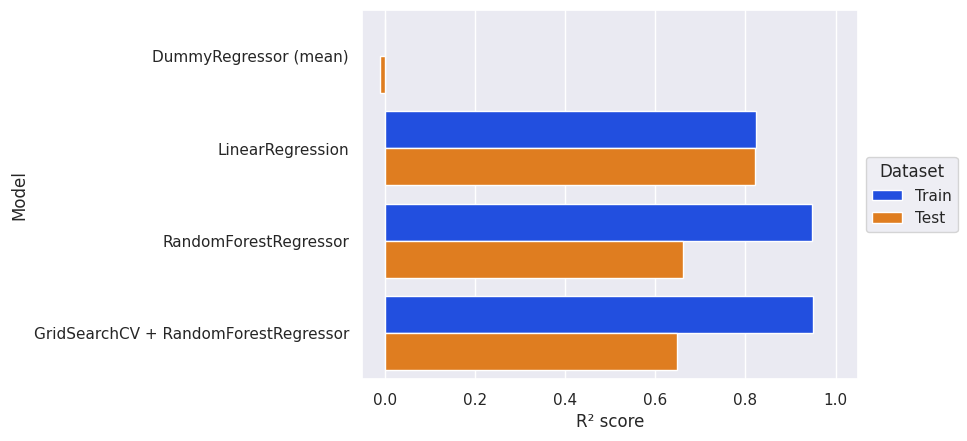

In [60]:
sns.barplot(df_r2_score, y="Model", x="R² score", hue="Dataset")
plt.xlim(-0.05, 1.05)
plt.legend(title="Dataset", loc="center left", bbox_to_anchor=(1,0.5))
plt.show()

In [61]:
df_rmse = df_results.rename(columns={"RMSE (train)":"Train","RMSE (test)":"Test"}).reset_index()
df_rmse = df_rmse.melt(id_vars=["Model"], value_vars=["Train","Test"], var_name="Dataset", value_name="RMSE")
df_rmse

,Model,Dataset,RMSE
0,DummyRegressor (mean),Train,122730.831186
1,LinearRegression,Train,15443.128144
2,RandomForestRegressor,Train,6092.093506
3,GridSearchCV + RandomForestRegressor,Train,8995.930611
4,DummyRegressor (mean),Test,105772.532809
5,LinearRegression,Test,16427.558958
6,RandomForestRegressor,Test,18567.405236
7,GridSearchCV + RandomForestRegressor,Test,28105.507174


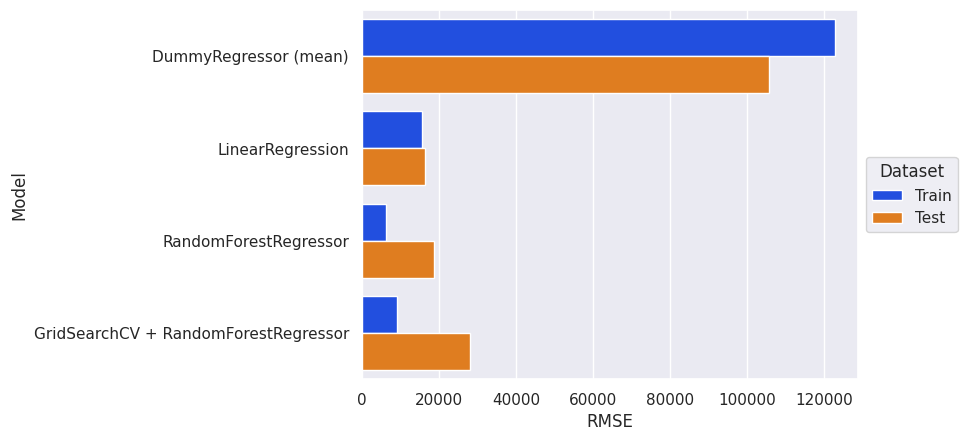

In [62]:
sns.barplot(df_rmse, y="Model", x="RMSE", hue="Dataset")
plt.legend(title="Dataset", loc="center left", bbox_to_anchor=(1,0.5))
plt.show()

In [63]:
df_mae = df_results.rename(columns={"MAE (train)":"Train","MAE (test)":"Test"}).reset_index()
df_mae = df_mae.melt(id_vars=["Model"], value_vars=["Train","Test"], var_name="Dataset", value_name="MAE")
df_mae

,Model,Dataset,MAE
0,DummyRegressor (mean),Train,45033.797353
1,LinearRegression,Train,4573.859413
2,RandomForestRegressor,Train,1587.856723
3,GridSearchCV + RandomForestRegressor,Train,2236.693786
4,DummyRegressor (mean),Test,44654.876264
5,LinearRegression,Test,5125.360893
6,RandomForestRegressor,Test,4808.755897
7,GridSearchCV + RandomForestRegressor,Test,6417.621234


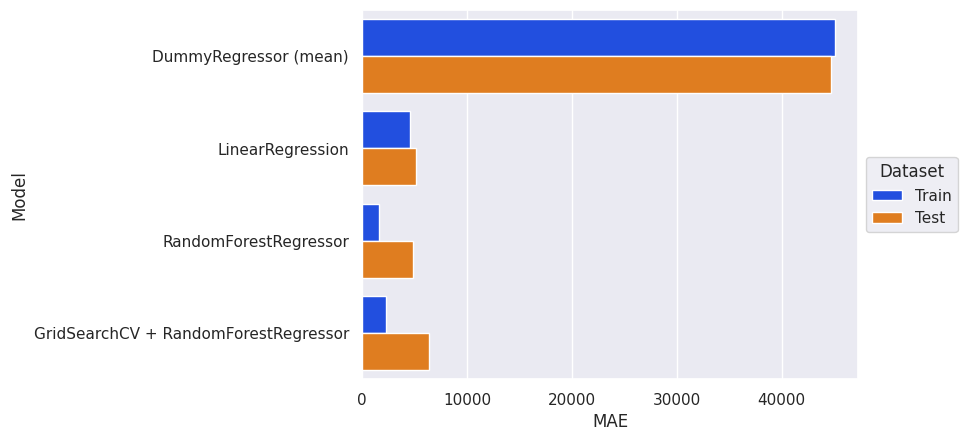

In [64]:
sns.barplot(df_mae, y="Model", x="MAE", hue="Dataset")
plt.legend(title="Dataset", loc="center left", bbox_to_anchor=(1,0.5))
plt.show()